In [1]:
%%time
import numpy as np
from utilities import states_from_fortran_restarts, setup_infrastructure

from pySHiELD.radiation import RadiationState, RadiationConfig, RTE_RRTMGPDriver
from pySHiELD.physics_state import SurfaceState, PhysicsState, PHYSICS_PACKAGES
from pySHiELD._config import PhysicsConfig
from pySHiELD.stencils.physics import Physics, flip_field_k

import matplotlib.pyplot as plt
import datetime
from pathlib import Path

2025-08-05 17:01:29|INFO|rank 0|ndsl.logging:Constant selected: ConstantVersions.UFS
CPU times: user 1.91 s, sys: 2.72 s, total: 4.63 s
Wall time: 2.78 s


In [2]:
dycore_data = Path("../../test_data/radtest/fv_core.res.tile1.nc")
phys_data = Path("../../test_data/radtest/phy_data.tile1.nc")
tracer_data = Path("../../test_data/radtest/fv_tracer.res.tile1.nc")

In [3]:
nx = 48
ny = 48
nz = 91
npx = nx + 1
npy = ny + 1
npz = nz + 1
levels = np.arange(npz)
layers = np.arange(nz)

date = datetime.datetime(2020, 1, 1, 12, tzinfo=datetime.timezone.utc)

In [4]:
quantity_factory, stencil_factory, grid_data = setup_infrastructure(nx, ny, nz, "eta91.nc")
# Quick fix:
grid_data.lon_agrid.field[:] = grid_data.lon.field[:-1,:-1]
grid_data.lat_agrid.field[:] = grid_data.lat.field[:-1,:-1]

In [5]:
conf = PhysicsConfig(
    dt_atmos=225.0,
    fhswr=225.0,
    fhlwr=225.0,
    npx=npx,
    npy=npy,
    npz=npz,
    nwat=6,
    prescribe_sst=False,
)
radconf = RadiationConfig(
    deltsw = 3600.0,
    delt_rad = 3600.0,
    date=date,
    fhswr=1.0,
    fhlwr=1.0,
    isolar=10,
    icmphys=4,
    ico2flg=0,
    ioznflg=1,
    ictmflg=-1,
    ialbflg=-1,
    iemsflg=0,
    ldisable_radiation_quasi_sea_ice=False,
    solar_constant_file=Path("global_solarconstant_noaa_an.txt"),
    input_dir=Path("../../test_data/"),
    aerosol_file=Path("../../test_data/"),
    sollat=0.0,
    nstp=6,
    ivflip=1,
    lcnorm=False,
    lcrick=False,
    gfs_cloud_overlap=False,
)

In [6]:
state, radstate, sstate = states_from_fortran_restarts(dycore_data, phys_data, tracer_data, grid_data.ak, quantity_factory, conf.schemes)
# state.prsi.field[0, 0, :]

In [7]:
prsl = (state.prsi.field[:, :, 1:] - state.prsi.field[:, :, :-1]) / np.log(state.prsi.field[:, :, 1:] / state.prsi.field[:, :, :-1])
# prsl[0,0,:]
# state.delp.field[:] = prsl

In [8]:
%%time
physics = Physics(
    stencil_factory,
    quantity_factory,
    grid_data,
    conf,
    radconf,
    hydro_delp=False,
)

2025-08-05 17:01:29|INFO|rank 0|ndsl.logging:GFS_microphysics enabled
2025-08-05 17:01:29|INFO|rank 0|ndsl.logging:RTE_RRTMGP enabled
2025-08-05 17:01:30|INFO|rank 0|ndsl.logging: - Using new fixed solar constant = 1360.8
2025-08-05 17:01:30|INFO|rank 0|ndsl.logging:Using Constant Albedo 0.98
2025-08-05 17:01:30|INFO|rank 0|ndsl.logging:Enable radiation quasi-sea-ice
2025-08-05 17:01:30|INFO|rank 0|ndsl.logging:Using Fixed Surface Emissivity = 1.0 for lw


/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dq` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `r1__f66_92_19` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `ze` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `zt` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/

CPU times: user 18.1 s, sys: 1.43 s, total: 19.5 s
Wall time: 19.9 s


In [9]:
%%time
physics(state, radstate, sstate, date, conf.dt_atmos)

2025-08-05 17:01:49|INFO|rank 0|ndsl.logging:Entering radiation
2025-08-05 17:02:01|INFO|rank 0|ndsl.logging:calling GFS microphysics
CPU times: user 8.5 s, sys: 3.47 s, total: 12 s
Wall time: 13.1 s


In [10]:
xcol, ycol = np.unravel_index(np.argmax(radstate.qliquid.field.sum(axis=2) + radstate.qice.field.sum(axis=2)), radstate.qliquid.field.sum(axis=2).shape)
print(xcol, ycol)
print(radstate.qliquid.field[xcol,ycol,:].sum())
print(grid_data.lon_agrid.field[xcol,ycol]*180/3.141, grid_data.lat_agrid.field[xcol, ycol]*180/3.141)
print(f"{date} UTC")

4 1
0.008406743662355522
-4.6883844519904985 9.61118812658052
2020-01-01 12:00:00+00:00 UTC


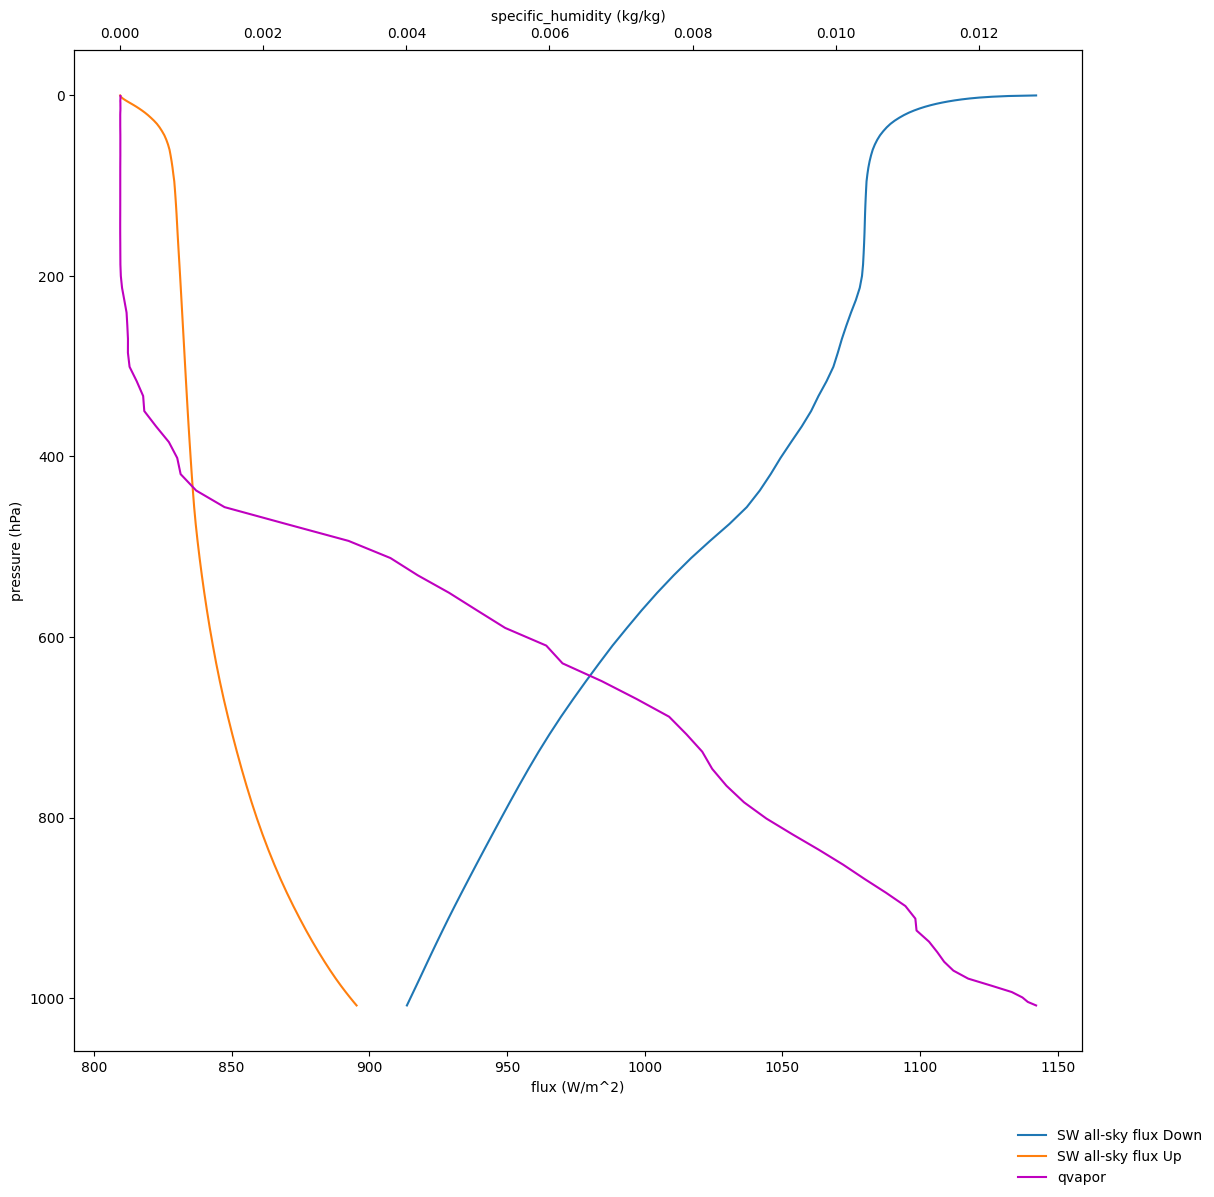

In [11]:
fig0 = plt.figure(0, figsize = (13,13))    #create  figure
f0ax1 = fig0.add_subplot(111) # define axes in which to plot
f0ax1.yaxis.set_inverted(True)
f0ax1.set_xlabel("flux (W/m^2)")
f0ax1.set_ylabel("pressure (hPa)")
f0ax1.plot(radstate.fswd.field[xcol, ycol,:], radstate.prsi.field[xcol, ycol, :]/100, label="SW all-sky flux Down")
f0ax1.plot(radstate.fswu.field[xcol, ycol,:], radstate.prsi.field[xcol, ycol, :]/100, label="SW all-sky flux Up")

f0ax2 = f0ax1.twiny()
f0ax2.set_xlabel("specific_humidity (kg/kg)")
f0ax2.plot(radstate.qvapor.field[xcol, ycol,:], radstate.prsi.field[xcol, ycol,:-1]/100, label="qvapor", color="m")

fig0.legend(frameon=False, loc=4)

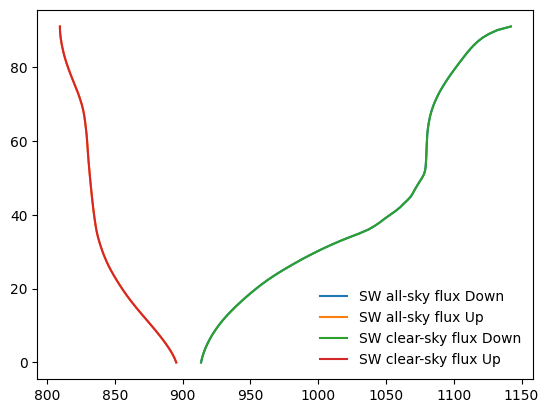

In [16]:
plt.plot(radstate.fswd.view[xcol, ycol,:], levels, label="SW all-sky flux Down")
plt.plot(radstate.fswu.view[xcol, ycol,:], levels, label="SW all-sky flux Up")
plt.plot(radstate.fswd_clr.view[xcol, ycol,:], levels, label="SW clear-sky flux Down")
plt.plot(radstate.fswu_clr.view[xcol, ycol,:], levels, label="SW clear-sky flux Up")
plt.legend(frameon=False)

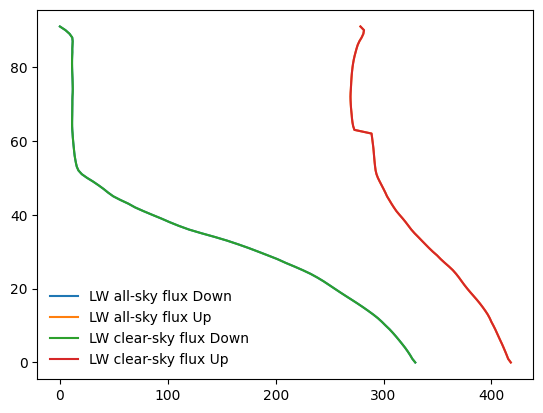

In [17]:
plt.plot(radstate.flwd.view[xcol, ycol,:], levels, label="LW all-sky flux Down")
plt.plot(radstate.flwu.view[xcol, ycol,:], levels, label="LW all-sky flux Up")
plt.plot(radstate.flwd_clr.view[xcol, ycol,:], levels, label="LW clear-sky flux Down")
plt.plot(radstate.flwu_clr.view[xcol, ycol,:], levels, label="LW clear-sky flux Up")
plt.legend(frameon=False)

In [25]:
radstate.qliquid.field[xcol, ycol, :]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 4.16966474e-05, 3.49139017e-04, 1.28316773e-04,
       1.11595633e-04, 1.33732718e-04, 1.53891879e-04, 1.77826125e-04,
       2.11452108e-04, 2.65290150e-04, 3.04137581e-04, 3.37437873e-04,
       3.72940979e-04, 4.40408298e-04, 5.03576985e-04, 5.94866727e-04,
       6.91676195e-04, 7.97985879e-04, 8.26357617e-04, 9.63071169e-04,
       7.03259430e-04, 2.97235131e-04, 8.48746811e-07, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      